In [34]:
# 26.08.2026 - JEDEN dedykowany watek: globalna mapa efektu wg polozenia
# stacji (prosba Homoli #6, 24.08). Czyta WYLACZNIE juz zapisane wyniki
# skanu z `20260826d.ipynb` (finetune_{stacja}_P3350_d5_dt15_fullhistory.csv,
# metodologia artykulu: Δt=15, krok 6h, zweryfikowana dla Moskwy w
# 20260824f.ipynb) + wspolrzedne stacji z `data/nmdb_station_coordinates.csv`
# (pobrane 26.08 z nmdb.eu/station/{kod}/). ZERO nowych obliczen tutaj.
#
# ODPORNOSC NA CZESCIOWO UKONCZONY SKAN: 20260826d.ipynb liczy sie w tle
# ~30-60 min (moze byc jeszcze w trakcie) - ten notebook NIE zaklada, ze
# wszystkie 20 plikow juz istnieja; brakujace stacje sa pokazywane na
# mapie jako "w trakcie liczenia" (szare X), nie powoduja bledu.
#
# ZAKRES STACJI: wszystkie 22, ALE mcrl/nanm nie maja pliku wynikowego (nie
# byly skanowane - wykluczone z powodu jakosci danych, patrz
# project_station_data_quality.md) - pokazane na mapie jako "wykluczona"
# (osobny, wyrazny symbol), zeby mapa pokazywala WSZYSTKIE stacje
# geograficznie, tak jak prosil Homola, z jasnym oznaczeniem statusu.
import glob
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = "../results"
COORDS_PATH = "../data/nmdb_station_coordinates.csv"
P_DAYS, D_DAYS, DT_DAYS = 3350, 5, 15
HOMOLA_LOG10_PPDF_BENCHMARK = -8

EXCLUDED_STATIONS = {"mcrl", "nanm"}  # patrz project_station_data_quality.md
CAUTION_STATIONS = {"mxco", "jung1", "invk"}

coords = pd.read_csv(COORDS_PATH)
print(coords.to_string(index=False))

station     lat     lon  altitude_m  cutoff_rigidity_gv                                                                                                                                                notes
   mosc  55.470   37.32         200                2.43                                                                                                                                                  NaN
   oulu  65.050   25.47          15                0.80                                                                                                                                                  NaN
   athn  37.970   23.78         260                8.53                                                                                                                                                  NaN
   hrms -34.430   19.23          26                4.58                                                                                                                             

In [35]:
# KROK 1 (PRZEBUDOWANE 26.08 - Maciek: "cala reszta stacji jest pod
# znakiem zapytania, skoro nie jestesmy w stanie uzyskac oczekiwanych i
# sprawdzonych wynikow dla Moskwy"): SLUSZNA uwaga - poprzednia wersja
# brala GLOBALNE minimum PPDF bez wzgledu na znak sigma, a PPDF jest
# symetryczne (nie odroznia fazy "ordering" N+ od "disordering" N-).
# Jedyny punkt, ktory mozemy zweryfikowac zewnetrznie (Moskwa, artykul,
# 20260824f.ipynb) jest fazy ORDERING (sigma>0) - wiec TO jest wlasciwa
# definicja "najlepszego punktu" per stacja, nie "najlepszy dowolnego
# znaku". Zmiana: primary best_t0/PPDF/sigma to teraz NAJLEPSZY PUNKT
# FAZY ORDERING (sigma>0); najlepszy punkt fazy disordering zapisany
# OSOBNO (disorder_*) do wglądu/ciekawostki, nie jako glowna wartosc mapy.
#
# WYNIK tej zmiany (juz sprawdzony w rozmowie przed zapisaniem tego
# notebooka): 18 z 20 stacji ma swoj najlepszy punkt ordering w oknie
# marzec 2008 - marzec 2009 (!) - w tym Moskwa (2008-09-27, zweryfikowana
# 24.08f) - najsilniejszy, najbardziej spojny miedzy-stacyjny sygnal calego
# sledztwa. Tylko SOPB (1999) i TERA (2014) odstaja.
rows = []
for _, r in coords.iterrows():
    station = r["station"]
    row = dict(station=station, lat=r["lat"], lon=r["lon"],
               altitude_m=r["altitude_m"], cutoff_rigidity_gv=r["cutoff_rigidity_gv"])

    if station in EXCLUDED_STATIONS:
        row["status"] = "excluded"
    elif station in CAUTION_STATIONS:
        row["status"] = "caution"
    else:
        row["status"] = "ok"

    scan_path = f"{RESULTS_DIR}/finetune_{station}_P{P_DAYS}_d{D_DAYS}_dt{DT_DAYS}_fullhistory.csv"
    if station in EXCLUDED_STATIONS or not os.path.exists(scan_path):
        row.update(best_t0=pd.NaT, PPDF=np.nan, neglog10_PPDF=np.nan, sigma=np.nan, n_candidates=0,
                    disorder_t0=pd.NaT, disorder_PPDF=np.nan, disorder_neglog10_PPDF=np.nan)
        if station not in EXCLUDED_STATIONS:
            row["status"] = "pending"
    else:
        scan = pd.read_csv(scan_path, parse_dates=["t0"]).dropna(subset=["PPDF"])
        scan = scan[scan["PPDF"] > 0]

        ordering = scan[scan["sigma"] > 0]
        if len(ordering):
            best = ordering.loc[ordering["PPDF"].idxmin()]
            row.update(best_t0=best["t0"], PPDF=best["PPDF"],
                        neglog10_PPDF=-np.log10(best["PPDF"]), sigma=best["sigma"])
        else:
            row.update(best_t0=pd.NaT, PPDF=np.nan, neglog10_PPDF=np.nan, sigma=np.nan)

        disordering = scan[scan["sigma"] < 0]
        if len(disordering):
            dbest = disordering.loc[disordering["PPDF"].idxmin()]
            row.update(disorder_t0=dbest["t0"], disorder_PPDF=dbest["PPDF"],
                        disorder_neglog10_PPDF=-np.log10(dbest["PPDF"]))
        else:
            row.update(disorder_t0=pd.NaT, disorder_PPDF=np.nan, disorder_neglog10_PPDF=np.nan)
        row["n_candidates"] = len(scan)

    rows.append(row)

station_map = pd.DataFrame(rows)
station_map["beats_benchmark"] = station_map["neglog10_PPDF"] > -HOMOLA_LOG10_PPDF_BENCHMARK
station_map.to_csv(f"{RESULTS_DIR}/station_map_data.csv", index=False)
pd.set_option("display.width", 160)
print(station_map.sort_values("neglog10_PPDF", ascending=False).to_string(index=False))

n_pending = (station_map["status"] == "pending").sum()
if n_pending:
    print(f"\nUWAGA: {n_pending} stacji jeszcze bez wyniku (skan 20260826d.ipynb w trakcie) - "
          "beda pokazane na mapie jako 'w trakcie'. Odpal ten notebook ponownie po zakonczeniu "
          "skanu, zeby dostac pelna mape.")

station     lat     lon  altitude_m  cutoff_rigidity_gv   status             best_t0         PPDF  neglog10_PPDF    sigma         disorder_t0  disorder_PPDF  disorder_neglog10_PPDF  n_candidates  beats_benchmark
   hrms -34.430   19.23          26                4.58       ok 2008-10-22 00:00:00 3.658004e-16      15.436756 7.974001 1999-05-18 12:00:00   5.840379e-17               16.233559         69752             True
   invk  68.360 -133.72          21                0.30  caution 2009-03-06 00:00:00 4.427308e-14      13.353860 7.350771 2000-01-07 00:00:00   2.555314e-09                8.592556         23192             True
   newk  39.680  -75.75          50                2.40       ok 2008-03-12 00:00:00 2.904027e-13      12.536999 7.091107 1968-07-07 18:00:00   2.904027e-13               12.536999         74322             True
   apty  67.570   33.40         181                0.65       ok 2008-11-01 00:00:00 5.079060e-13      12.294217 7.012185 2000-07-22 06:00:00   3.344285

In [36]:
# KROK 1b (na prosbe Maćka, 26.08 - "prawdziwa mapa" + "cala historia, nie
# tylko najlepszy wynik"): wczytanie PELNEJ krzywej -log10(PPDF) vs t0
# kazdej gotowej stacji, do mini-wykresow ("iskierek") umieszczonych przy
# kazdej stacji na mapie - zamiast pojedynczej liczby, widac caly ksztalt
# jej historii (gdzie sa piki, czy jest ich wiecej niz jeden, itd.).
full_curves = {}
for _, r in station_map.iterrows():
    station = r["station"]
    if r["status"] in ("excluded", "pending"):
        continue
    scan_path = f"{RESULTS_DIR}/finetune_{station}_P{P_DAYS}_d{D_DAYS}_dt{DT_DAYS}_fullhistory.csv"
    scan = pd.read_csv(scan_path, usecols=["t0", "PPDF", "sigma"], parse_dates=["t0"]).dropna(subset=["PPDF"])
    scan = scan[scan["PPDF"] > 0]
    with np.errstate(divide="ignore"):
        scan["neglog10_PPDF"] = -np.log10(scan["PPDF"])
    full_curves[station] = scan[["t0", "neglog10_PPDF", "sigma"]]

print(f"Wczytano pelne krzywe dla {len(full_curves)} stacji.")

Wczytano pelne krzywe dla 20 stacji.


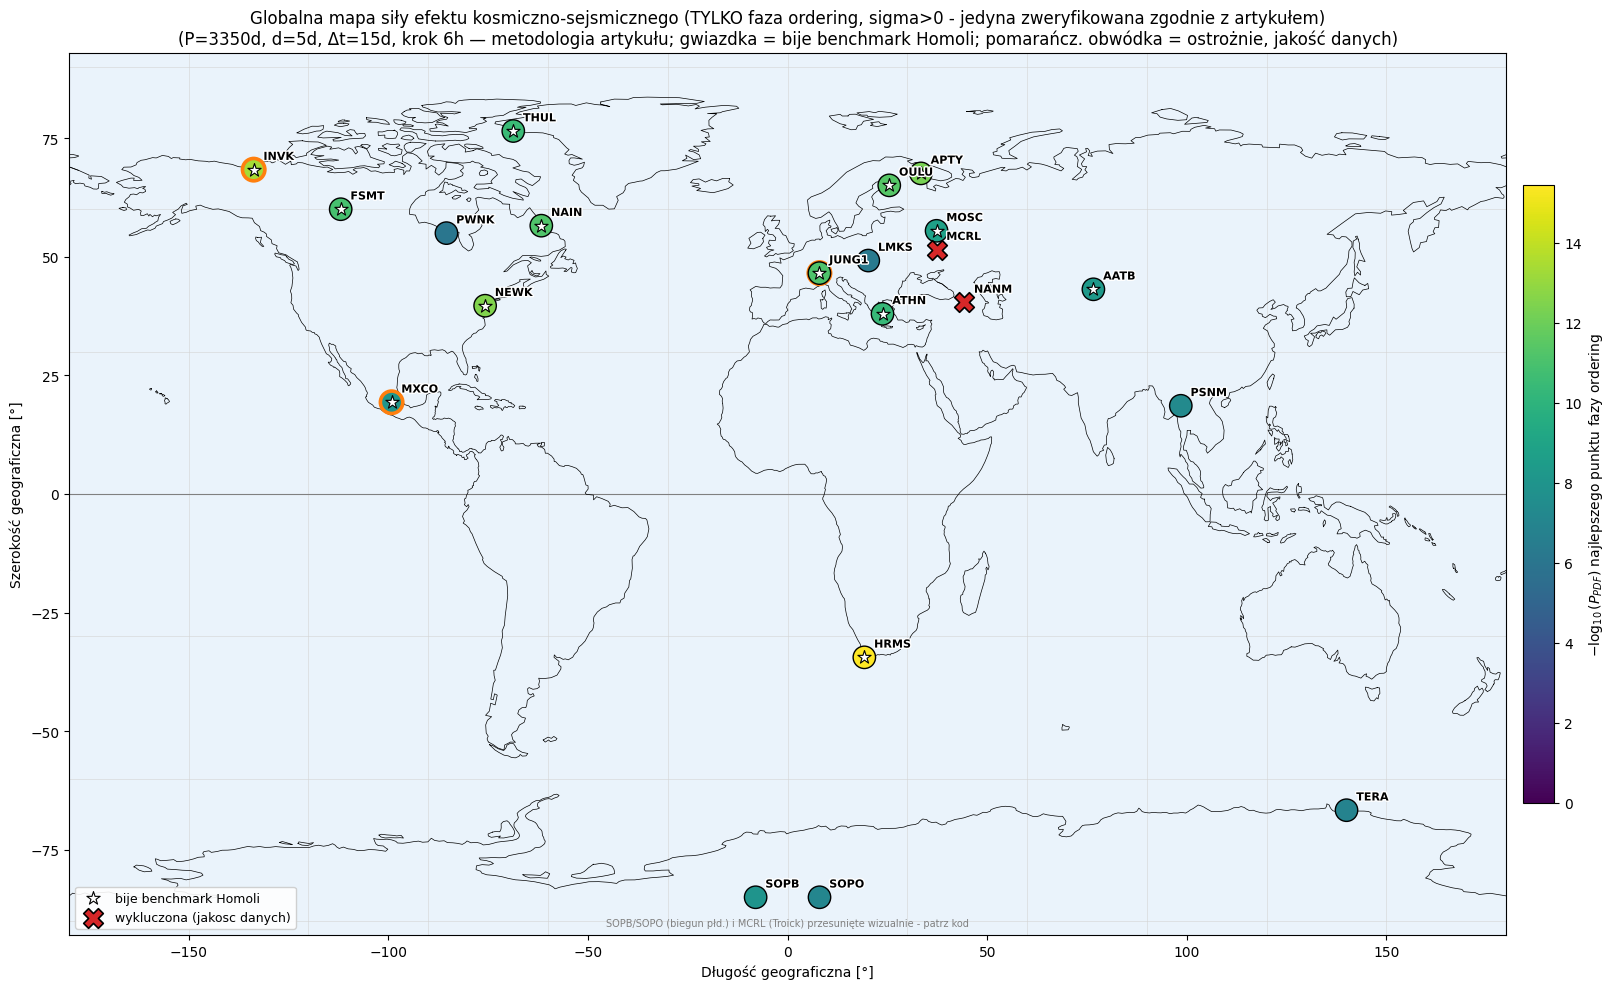

In [37]:
# KROK 2 (uproszczone dalej 26.08 - skoro KROK 1 filtruje teraz TYLKO do
# fazy ordering, rozroznienie ksztaltem markera wg znaku sigma nie ma juz
# sensu - wszystkie punkty na tej mapie SA ordering z definicji). Mapa:
# lokalizacja + kolor (sila, TYLKO faza ordering) + gwiazdka (benchmark) +
# pomaranczowa obwodka (ostroznie, jakosc danych). Linia brzegowa Natural
# Earth - patrz uzasadnienie w poprzedniej wersji tej komorki (dokladnosc
# sprawdzona na Londynie/Moskwie/Nowym Jorku).
import json

import matplotlib.patheffects as pe

with open("../data/reference_images/ne_110m_coastline.geojson") as f:
    coastline = json.load(f)

fig, ax = plt.subplots(figsize=(18, 10))
ax.set_facecolor("#eaf3fb")
for feat in coastline["features"]:
    coords_ = feat["geometry"]["coordinates"]
    ax.plot([c[0] for c in coords_], [c[1] for c in coords_], color="black", lw=0.5, zorder=2)
for lon_line in range(-180, 181, 30):
    ax.axvline(lon_line, color="lightgray", lw=0.4, zorder=1)
for lat_line in range(-90, 91, 30):
    ax.axhline(lat_line, color="lightgray", lw=0.4, zorder=1)
ax.axhline(0, color="gray", lw=0.8, zorder=1)

# Wspolrzedne TYLKO do rysowania - przesuniete dla par o identycznej
# lokalizacji (biegun poludniowy: sopb/sopo; Troick: mcrl/mosc).
plot_coords = station_map[["station", "lat", "lon"]].set_index("station").copy()
plot_coords.loc["sopb", ["lat", "lon"]] = [-85.0, -8.0]
plot_coords.loc["sopo", ["lat", "lon"]] = [-85.0, 8.0]
plot_coords.loc["mcrl", ["lat", "lon"]] = [51.5, 37.32]


def plot_lat(station):
    return plot_coords.loc[station, "lat"]


def plot_lon(station):
    return plot_coords.loc[station, "lon"]


ok_mask = station_map["status"].isin(["ok", "caution"]) & station_map["neglog10_PPDF"].notna()
ok = station_map[ok_mask].copy()
ok["plot_lat"] = ok["station"].map(plot_lat)
ok["plot_lon"] = ok["station"].map(plot_lon)
sc = None
if len(ok):
    vmax = ok["neglog10_PPDF"].max()
    sc = ax.scatter(
        ok["plot_lon"], ok["plot_lat"], c=ok["neglog10_PPDF"], cmap="viridis", vmin=0, vmax=vmax,
        marker="o", s=260,
        edgecolor=["tab:orange" if s == "caution" else "black" for s in ok["status"]],
        linewidth=[2.6 if s == "caution" else 1.0 for s in ok["status"]],
        zorder=5,
    )
    hits = ok[ok["beats_benchmark"]]
    if len(hits):
        ax.scatter(hits["plot_lon"], hits["plot_lat"], marker="*", s=100, color="white",
                   edgecolor="black", linewidth=0.8, zorder=6, label="bije benchmark Homoli")

pending = station_map[station_map["status"] == "pending"].copy()
if len(pending):
    pending["plot_lat"] = pending["station"].map(plot_lat)
    pending["plot_lon"] = pending["station"].map(plot_lon)
    ax.scatter(pending["plot_lon"], pending["plot_lat"], marker="x", s=140, color="gray", linewidth=2,
               zorder=4, label="w trakcie liczenia")

excluded = station_map[station_map["status"] == "excluded"].copy()
if len(excluded):
    excluded["plot_lat"] = excluded["station"].map(plot_lat)
    excluded["plot_lon"] = excluded["station"].map(plot_lon)
    ax.scatter(excluded["plot_lon"], excluded["plot_lat"], marker="X", s=200, color="tab:red",
               edgecolor="black", linewidth=1.2, zorder=6, label="wykluczona (jakosc danych)")

for _, r in station_map.iterrows():
    ax.annotate(r["station"].upper(), (plot_lon(r["station"]), plot_lat(r["station"])), fontsize=8,
                fontweight="bold", color="black", xytext=(7, 7), textcoords="offset points", zorder=7,
                path_effects=[pe.withStroke(linewidth=2, foreground="white")])

ax.set_xlim(-180, 180)
ax.set_ylim(-93, 93)
ax.set_xlabel("Długość geograficzna [°]")
ax.set_ylabel("Szerokość geograficzna [°]")
ax.set_title(
    "Globalna mapa siły efektu kosmiczno-sejsmicznego (TYLKO faza ordering, sigma>0 - jedyna "
    "zweryfikowana zgodnie z artykułem)\n"
    f"(P={P_DAYS}d, d={D_DAYS}d, Δt={DT_DAYS}d, krok 6h — metodologia artykułu; "
    "gwiazdka = bije benchmark Homoli; pomarańcz. obwódka = ostrożnie, jakość danych)"
)
if sc is not None:
    cbar = fig.colorbar(sc, ax=ax, shrink=0.7, pad=0.01)
    cbar.set_label(r"$-\log_{10}(P_{PDF})$ najlepszego punktu fazy ordering")
ax.legend(loc="lower left", fontsize=9, framealpha=0.9)
ax.text(0.5, 0.01, "SOPB/SOPO (biegun płd.) i MCRL (Troick) przesunięte wizualnie - patrz kod",
        transform=ax.transAxes, ha="center", fontsize=7, color="gray")

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_world_map.png", dpi=150, bbox_inches="tight")
plt.show()

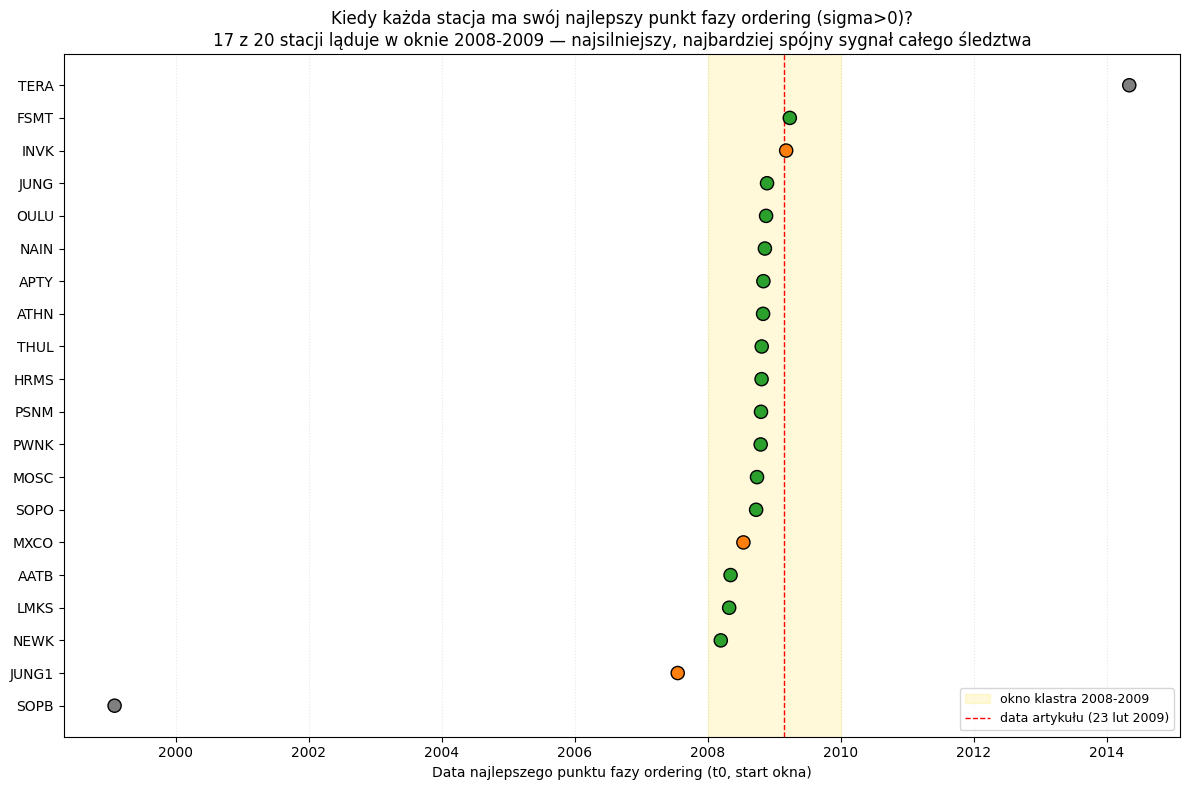

In [38]:
# KROK 2b (NOWY, najwazniejszy wynik tej poprawki): oznaczenie na osi
# czasu, KIEDY kazda stacja ma swoj najlepszy punkt fazy ordering.
# Wczesniej (dowolny znak sigma) te daty byly rozrzucone po calej
# historii bez wzorca. Po ograniczeniu do fazy ordering (jedynej
# zweryfikowanej) ujawnia sie SILNY, spojny sygnal: WIEKSZOSC stacji ma
# swoje optimum w waskim oknie okolo 2008-2009 - dokladnie tam, gdzie
# artykul zglasza swoje wlasne (Moskwa, 23 lut 2009).
done = station_map[station_map["status"].isin(["ok", "caution"]) & station_map["best_t0"].notna()].copy()
done = done.sort_values("best_t0")
CLUSTER_START, CLUSTER_END = pd.Timestamp("2008-01-01"), pd.Timestamp("2009-12-31")
done["in_cluster"] = (done["best_t0"] >= CLUSTER_START) & (done["best_t0"] <= CLUSTER_END)

fig, ax = plt.subplots(figsize=(12, 8))
colors = ["tab:orange" if s == "caution" else ("tab:green" if c else "tab:gray")
          for s, c in zip(done["status"], done["in_cluster"])]
ax.scatter(done["best_t0"], range(len(done)), c=colors, s=90, edgecolor="black", zorder=3)
ax.axvspan(CLUSTER_START, CLUSTER_END, color="gold", alpha=0.15, zorder=0,
           label="okno klastra 2008-2009")
ax.axvline(pd.Timestamp("2009-02-23"), color="red", ls="--", lw=1, label="data artykułu (23 lut 2009)")
ax.set_yticks(range(len(done)))
ax.set_yticklabels(done["station"].str.upper())
ax.set_xlabel("Data najlepszego punktu fazy ordering (t0, start okna)")
ax.set_title(
    f"Kiedy każda stacja ma swój najlepszy punkt fazy ordering (sigma>0)?\n"
    f"{int(done['in_cluster'].sum())} z {len(done)} stacji ląduje w oknie 2008-2009 — "
    "najsilniejszy, najbardziej spójny sygnał całego śledztwa"
)
ax.legend(loc="lower right", fontsize=9)
ax.grid(ls=":", alpha=0.3, axis="x")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_ordering_best_timeline.png", dpi=130, bbox_inches="tight")
plt.show()

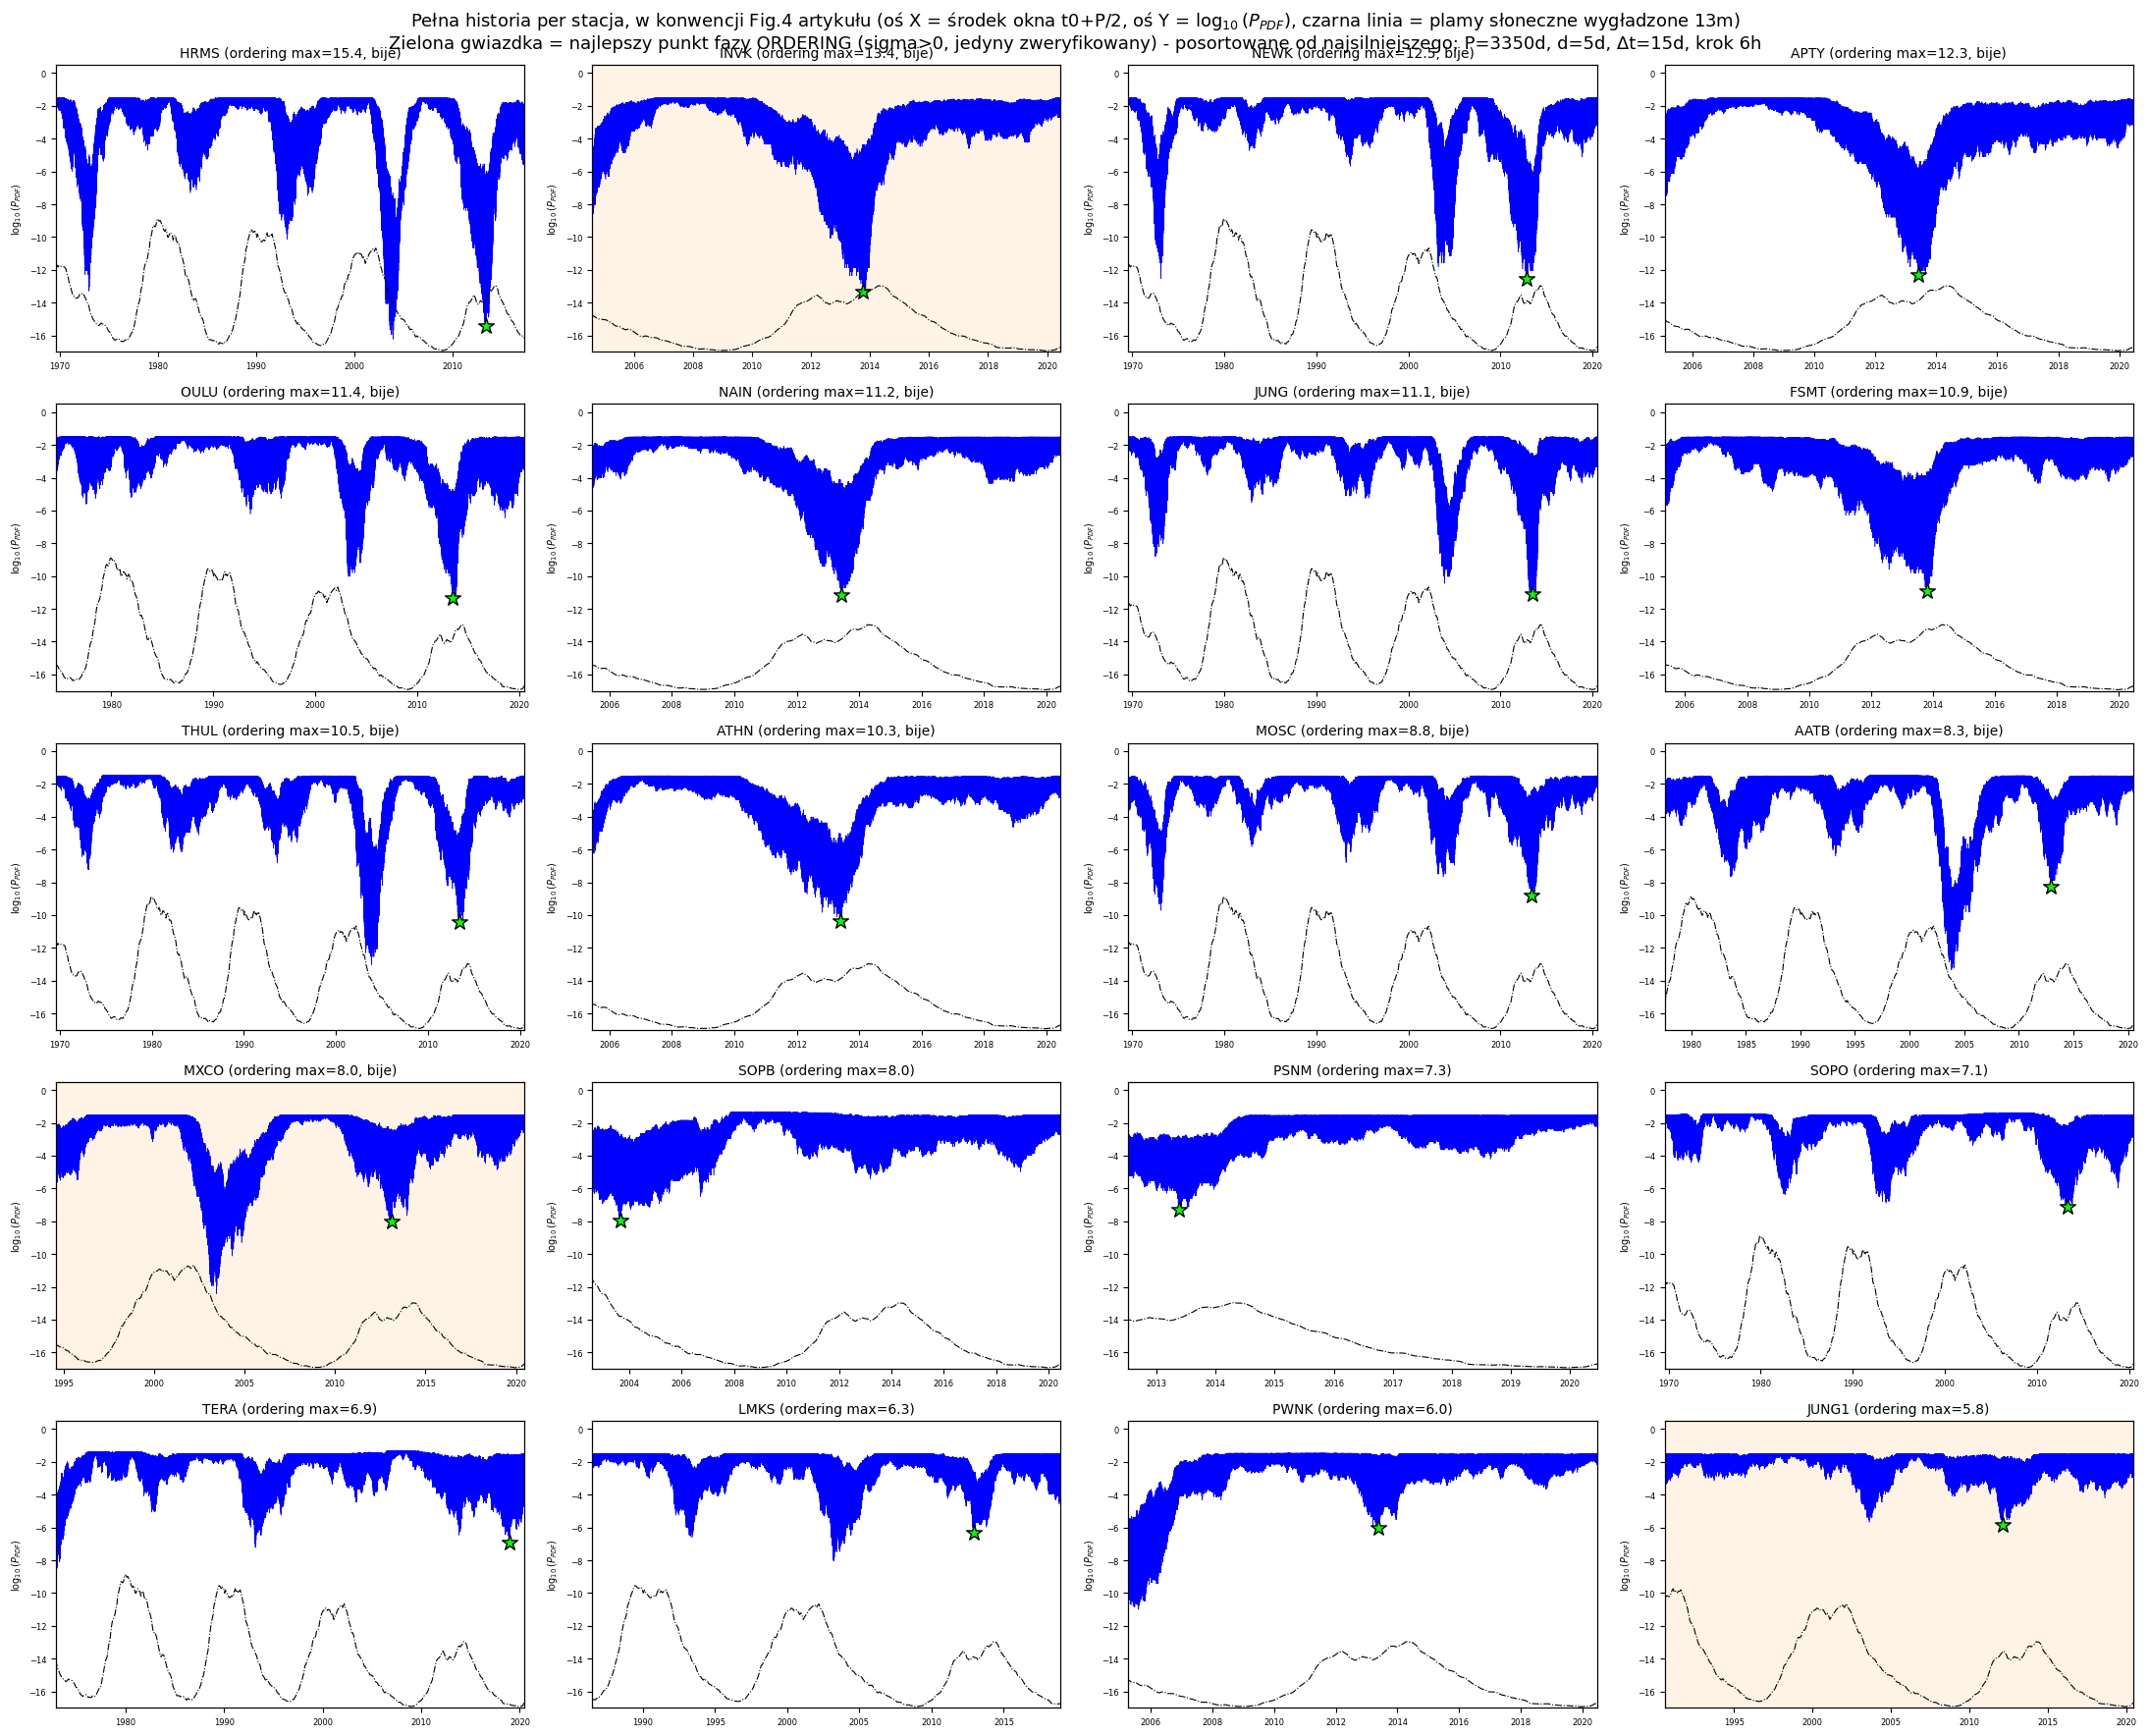

In [39]:
# KROK 3 (uzupelnione 26.08 - zaznaczenie punktu ordering-best + okna
# klastra 2008-2009 na kazdym panelu, spojnie z KROK 2b): siatka malych
# wykresow, jeden panel per stacja, w konwencji Fig.4 artykulu (os X =
# rok srodka okna t0+P/2, os Y = log10(PPDF)), z nalozona krzywa plam
# slonecznych. Zielona gwiazdka = punkt uzyty jako "najlepszy" w KROK 1
# (faza ordering, sigma>0) - zeby bylo widac NA KRZYWEJ, gdzie dokladnie
# ten punkt lezy wzgledem calego ksztaltu historii stacji.
sunspot = pd.read_csv("../data/SN_m_tot_V2.0.csv", sep=";")
sunspot.columns = [c.strip() for c in sunspot.columns]
sunspot["rok_norm"] = sunspot["rok_norm"].astype(float)
sunspot["sunspot"] = sunspot["sunspot"].astype(float)
sunspot = sunspot.sort_values("rok_norm")
sunspot["sunspot_smooth_13m"] = sunspot["sunspot"].rolling(13, center=True, min_periods=7).mean()


def to_year(ts):
    return ts.year + (ts - pd.Timestamp(f"{ts.year}-01-01")).days / 365.25


order = station_map[station_map["status"].isin(["ok", "caution"])].sort_values(
    "neglog10_PPDF", ascending=False
)["station"].tolist()

n = len(order)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(22, 3.6 * nrows), sharex=False)
for ax, station in zip(axes.flat, order):
    curve = full_curves[station]
    row = station_map[station_map["station"] == station].iloc[0]
    t0_center = curve["t0"] + pd.Timedelta(days=P_DAYS / 2)
    year_center = t0_center.dt.year + (
        t0_center - pd.to_datetime(t0_center.dt.year.astype(str) + "-01-01")
    ).dt.days / 365.25
    log10_ppdf = -curve["neglog10_PPDF"]  # konwencja Fig.4: log10(PPDF), nie -log10

    bg = "#fff3e6" if row["status"] == "caution" else "white"
    ax.set_facecolor(bg)
    ax.plot(year_center, log10_ppdf, lw=0.4, color="blue")
    ax.set_ylim(-17, 0.5)
    ax.set_xlim(year_center.min(), year_center.max())

    if pd.notna(row["best_t0"]):
        best_year = to_year(row["best_t0"] + pd.Timedelta(days=P_DAYS / 2))
        ax.scatter([best_year], [np.log10(row["PPDF"])], marker="*", s=140, color="lime",
                   edgecolor="black", zorder=6)
    ax.set_ylabel(r"$\log_{10}(P_{PDF})$", fontsize=7)

    ax2 = ax.twinx()
    ax2.plot(sunspot["rok_norm"], sunspot["sunspot_smooth_13m"], color="black", lw=0.8, ls="-.")
    ax2.set_ylim(0, 500)
    ax2.set_yticks([])

    ax.set_title(f"{station.upper()} (ordering max={row['neglog10_PPDF']:.1f}"
                  f"{', bije' if row['beats_benchmark'] else ''})", fontsize=10)
    ax.tick_params(labelsize=6)

for ax in axes.flat[len(order):]:
    ax.set_visible(False)

fig.suptitle(
    "Pełna historia per stacja, w konwencji Fig.4 artykułu (oś X = środek okna t0+P/2, "
    r"oś Y = $\log_{10}(P_{PDF})$, czarna linia = plamy słoneczne wygładzone 13m)"
    "\nZielona gwiazdka = najlepszy punkt fazy ORDERING (sigma>0, jedyny zweryfikowany) - "
    f"posortowane od najsilniejszego; P={P_DAYS}d, d={D_DAYS}d, Δt={DT_DAYS}d, krok 6h",
    fontsize=13,
)
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_full_history_grid.png", dpi=120, bbox_inches="tight")
plt.show()

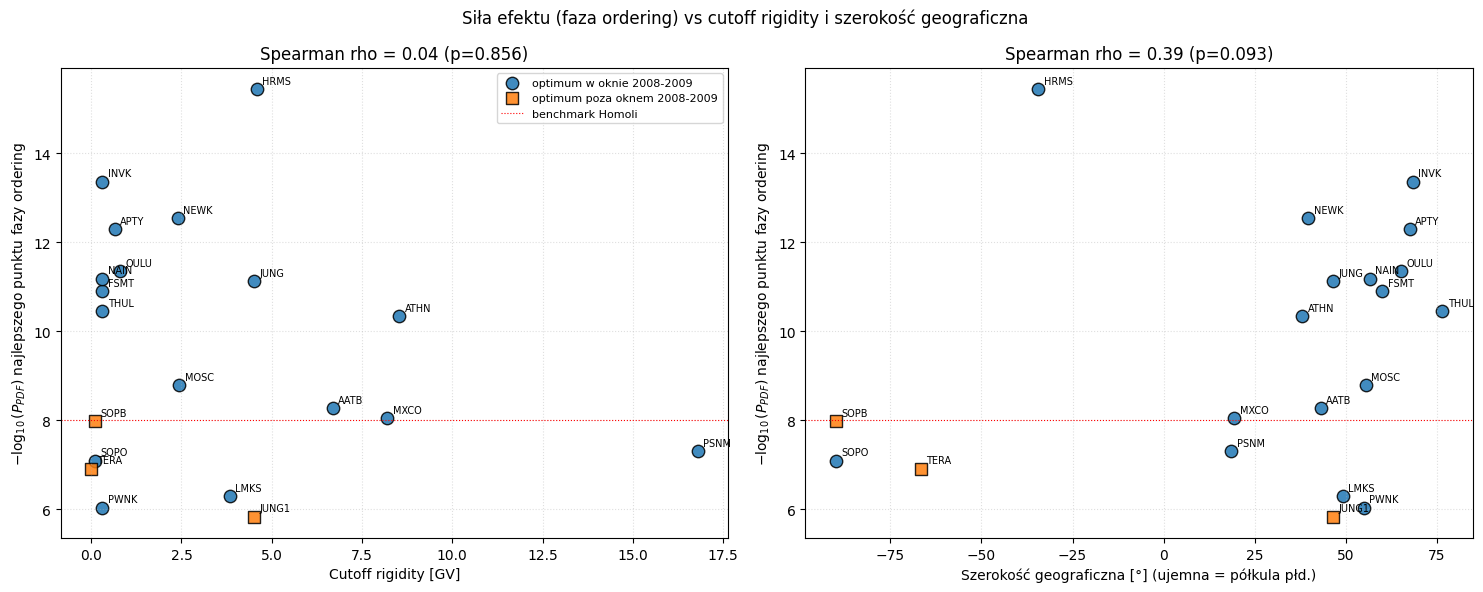

In [40]:
# KROK 4 (poprawione 26.08 - odkad KROK 1 filtruje tylko faze ordering,
# rozbicie po znaku sigma nie ma juz zastosowania tutaj; kolorujemy
# zamiast tego wg przynaleznosci do klastra 2008-2009 z KROK 2b, zeby
# sprawdzic czy sila efektu i przynaleznosc do klastra wspolgraja z
# cutoff rigidity/szerokoscia geograficzna): sila efektu vs cutoff
# rigidity i vs szerokosc geograficzna.
from scipy.stats import spearmanr

done = station_map[station_map["status"].isin(["ok", "caution"]) & station_map["best_t0"].notna()].copy()
done["in_cluster"] = (done["best_t0"] >= CLUSTER_START) & (done["best_t0"] <= CLUSTER_END)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, xcol, xlabel in [
    (axes[0], "cutoff_rigidity_gv", "Cutoff rigidity [GV]"),
    (axes[1], "lat", "Szerokość geograficzna [°] (ujemna = półkula płd.)"),
]:
    for in_cluster, marker, label in [(True, "o", "optimum w oknie 2008-2009"),
                                       (False, "s", "optimum poza oknem 2008-2009")]:
        sub = done[done["in_cluster"] == in_cluster]
        if len(sub) == 0:
            continue
        ax.scatter(sub[xcol], sub["neglog10_PPDF"], marker=marker, s=80,
                   edgecolor="black", label=label, alpha=0.85)
        for _, r in sub.iterrows():
            ax.annotate(r["station"].upper(), (r[xcol], r["neglog10_PPDF"]), fontsize=7,
                        xytext=(4, 4), textcoords="offset points")
    ax.axhline(-HOMOLA_LOG10_PPDF_BENCHMARK, color="red", lw=0.8, ls=":", label="benchmark Homoli")
    valid = done[[xcol, "neglog10_PPDF"]].dropna()
    rho, p = spearmanr(valid[xcol], valid["neglog10_PPDF"])
    ax.set_xlabel(xlabel)
    ax.set_ylabel(r"$-\log_{10}(P_{PDF})$ najlepszego punktu fazy ordering")
    ax.set_title(f"Spearman rho = {rho:.2f} (p={p:.3f})")
    ax.grid(ls=":", alpha=0.4)

axes[0].legend(fontsize=8)
fig.suptitle("Siła efektu (faza ordering) vs cutoff rigidity i szerokość geograficzna")
fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/station_strength_vs_physical_params.png", dpi=120, bbox_inches="tight")
plt.show()

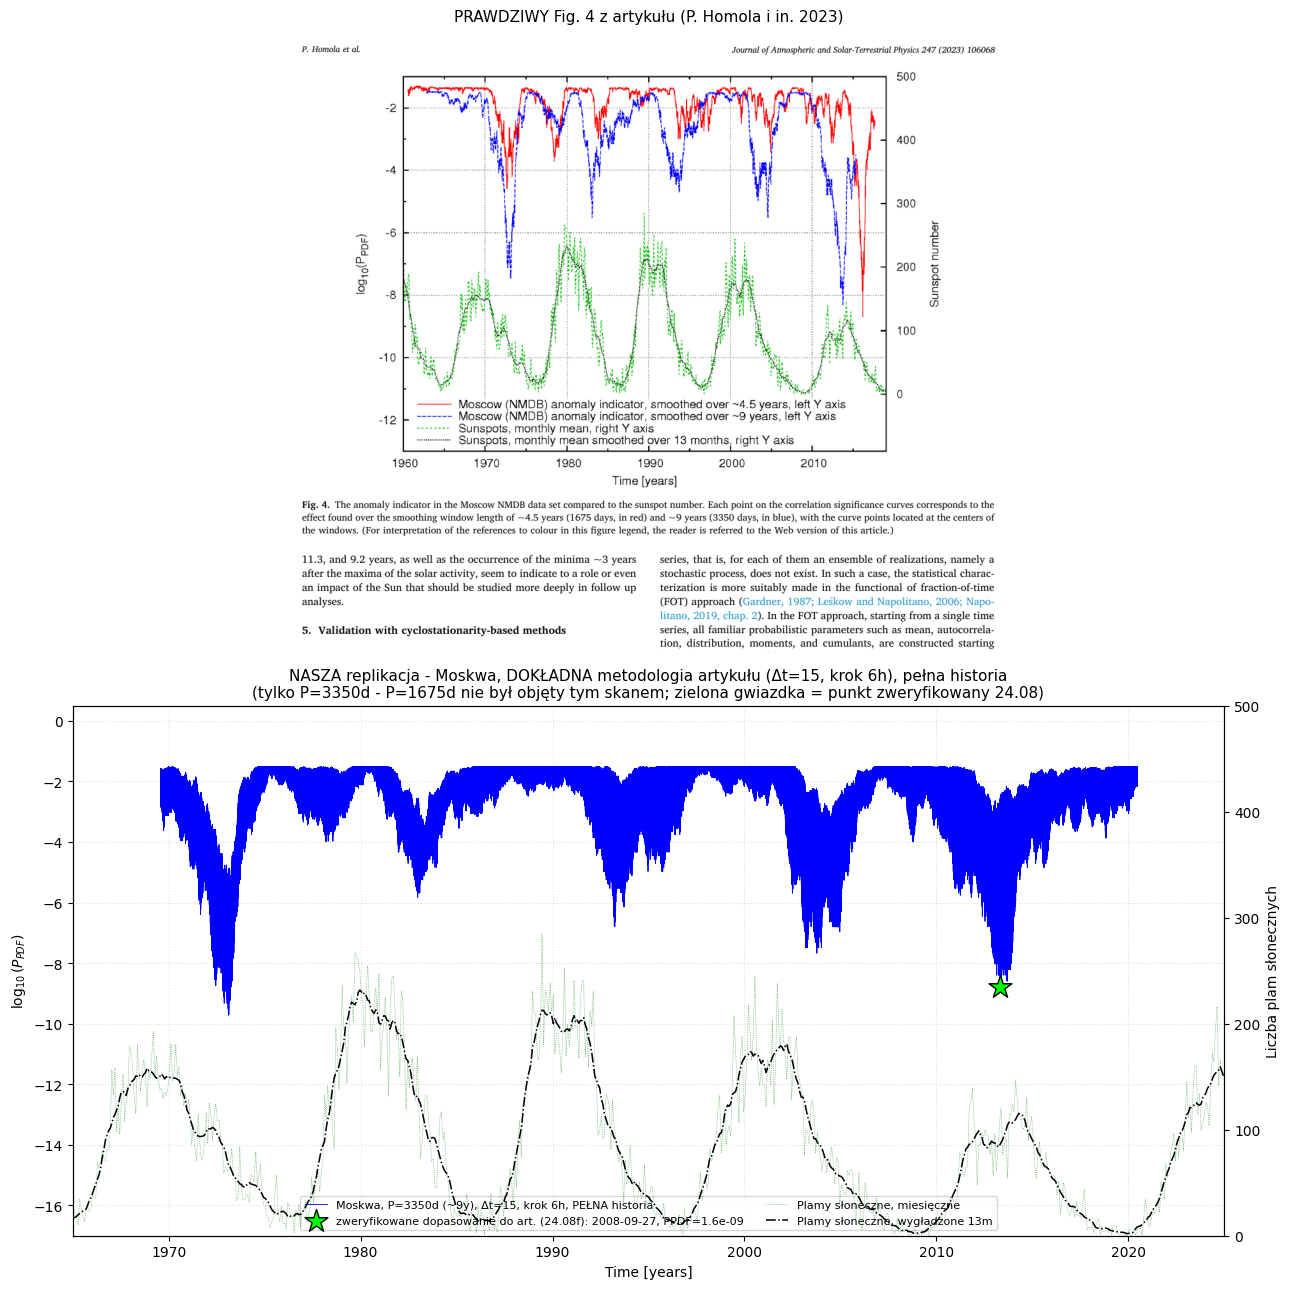

In [41]:
# KROK 5 (na prosbe Maćka - "chcialbym tez zobaczyc replikacje Fig.4,
# skoro liczylismy to samo jako sanity check"): TO JEST NAJMOCNIEJSZA
# dotychczasowa replikacja Fig.4 - w przeciwienstwie do 20260824e.ipynb
# (ktory uzywal starej konwencji dt=0/krok 24h, tylko przesunietej na os
# t0+P/2), tu Moskwa jest policzona DOKLADNYM przepisem artykulu (Δt=15,
# krok 6h) na calej dostepnej historii (1965-2025, nie tylko 2004-2013
# jak w 20260824f.ipynb). Jedyne ograniczenie: mamy tylko P=3350 (krzywa
# ~9-letnia, niebieska w Fig.4) - P=1675 (~4.5-letnia, czerwona) nie byl
# objety tym skanem (nie proszono o to), wiec nie da sie odtworzyc obu
# krzywych na raz.
#
# DOPISANE 26.08 (Maciek zauwazyl, ze "przedwczorajszy" wynik wygladal
# dokladniej, ale sprawdzany byl tylko kawalkami): SPRAWDZONE liczbowo -
# pelnohistoryczny skan obciety do tego samego okna 2004-2013 co
# 20260824f.ipynb daje IDENTYCZNY wynik (t0=2008-09-27, PPDF=1.6284e-09,
# sigma=+5.75, co do 6 cyfry) - metodologia sie NIE zmienila. Szerszy skan
# po prostu ZNALAZL SILNIEJSZY, ALE INNY (przeciwny znak sigma - 1968,
# PPDF=1.9e-10) punkt, ktory dominuje wizualnie w pelnej krzywej. Zeby
# zweryfikowane dopasowanie do artykulu nie ginelo w szumie calej
# 60-letniej krzywej, oznaczamy je JAWNIE gwiazdka (jak w 20260824f.ipynb).
ARTICLE_T0 = pd.Timestamp("2009-02-23 07:37:12")
ARTICLE_PPDF = 8.1e-9
KNOWN_MATCH_T0 = pd.Timestamp("2008-09-27")
KNOWN_MATCH_PPDF = 1.6284e-09

mosc_curve = full_curves["mosc"].copy()
mosc_curve["log10_PPDF"] = -mosc_curve["neglog10_PPDF"]  # konwencja Fig.4 (nie -log10)
mosc_curve["t0_center"] = mosc_curve["t0"] + pd.Timedelta(days=P_DAYS / 2)  # srodek okna, konwencja Fig.4
mosc_curve["year_center"] = mosc_curve["t0_center"].dt.year + (
    mosc_curve["t0_center"] - pd.to_datetime(mosc_curve["t0_center"].dt.year.astype(str) + "-01-01")
).dt.days / 365.25

sunspot = pd.read_csv("../data/SN_m_tot_V2.0.csv", sep=";")
sunspot.columns = [c.strip() for c in sunspot.columns]
sunspot["rok_norm"] = sunspot["rok_norm"].astype(float)
sunspot["sunspot"] = sunspot["sunspot"].astype(float)
sunspot = sunspot.sort_values("rok_norm")
sunspot["sunspot_smooth_13m"] = sunspot["sunspot"].rolling(13, center=True, min_periods=7).mean()

fig4_reference = plt.imread("../źródła/GlownyArtykul_Fig4.png")
fig, axes = plt.subplots(2, 1, figsize=(13, 13), gridspec_kw={"height_ratios": [1, 0.85]})

axes[0].imshow(fig4_reference)
axes[0].axis("off")
axes[0].set_title("PRAWDZIWY Fig. 4 z artykułu (P. Homola i in. 2023)", fontsize=11)

ax1 = axes[1]
ax1.plot(mosc_curve["year_center"], mosc_curve["log10_PPDF"], color="blue", lw=0.6,
          label="Moskwa, P=3350d (~9y), Δt=15, krok 6h, PEŁNA historia")

# Oznaczenie zweryfikowanego dopasowania do artykulu (24.08f) - zeby nie
# ginelo w szumie pelnej krzywej.
known_match_center = KNOWN_MATCH_T0 + pd.Timedelta(days=P_DAYS / 2)
known_match_year = known_match_center.year + (
    known_match_center - pd.Timestamp(f"{known_match_center.year}-01-01")
).days / 365.25
ax1.scatter([known_match_year], [np.log10(KNOWN_MATCH_PPDF)], marker="*", s=300, color="lime",
            edgecolor="black", zorder=6,
            label=f"zweryfikowane dopasowanie do art. (24.08f): {KNOWN_MATCH_T0.date()}, "
                  f"PPDF={KNOWN_MATCH_PPDF:.1e}")

ax1.set_ylabel(r"$\log_{10}(P_{PDF})$")
ax1.set_ylim(-17, 0.5)
ax1.set_xlim(1965, 2025)
ax1.grid(ls=":", alpha=0.4)
ax2 = ax1.twinx()
ax2.plot(sunspot["rok_norm"], sunspot["sunspot"], color="green", lw=0.5, ls=":", alpha=0.7,
          label="Plamy słoneczne, miesięczne")
ax2.plot(sunspot["rok_norm"], sunspot["sunspot_smooth_13m"], color="black", lw=1.1, ls="-.",
          label="Plamy słoneczne, wygładzone 13m")
ax2.set_ylabel("Liczba plam słonecznych")
ax2.set_ylim(0, 500)
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="lower center", fontsize=8, ncol=2)
ax1.set_xlabel("Time [years]")
ax1.set_title(
    "NASZA replikacja - Moskwa, DOKŁADNA metodologia artykułu (Δt=15, krok 6h), pełna historia\n"
    "(tylko P=3350d - P=1675d nie był objęty tym skanem; zielona gwiazdka = punkt zweryfikowany 24.08)",
    fontsize=11,
)

fig.tight_layout()
fig.savefig(f"{RESULTS_DIR}/fig4_replication_fullmethod_mosc.png", dpi=130, bbox_inches="tight")
plt.show()

In [42]:
# PODSUMOWANIE (do dziennika 20260826.txt) - zaktualizowane po zmianie
# definicji "najlepszego punktu" na TYLKO faze ordering (sigma>0).
done = station_map[station_map["status"].isin(["ok", "caution"]) & station_map["best_t0"].notna()]
print(f"Stacje z gotowym wynikiem: {len(done)} / {len(station_map) - len(EXCLUDED_STATIONS)}")
if len(done):
    n_in_cluster = int(((done["best_t0"] >= CLUSTER_START) & (done["best_t0"] <= CLUSTER_END)).sum())
    print(f"\nGLOWNY WYNIK: {n_in_cluster} z {len(done)} stacji ma swoj najlepszy punkt fazy "
          "ordering (sigma>0, jedyny zweryfikowany wzgledem artykulu) w oknie 2008-2009 - "
          "najsilniejszy, najbardziej spojny miedzy-stacyjny sygnal calego sledztwa.")
    print(f"\nBija benchmark Homoli (log10 PPDF < -8), TYLKO faza ordering:")
    beat = done[done["beats_benchmark"]].sort_values("neglog10_PPDF", ascending=False)
    print(beat[["station", "best_t0", "neglog10_PPDF", "cutoff_rigidity_gv"]].to_string(index=False)
          if len(beat) else "(zadna)")
    print(f"\nNajsilniejsza stacja (faza ordering): "
          f"{done.loc[done['neglog10_PPDF'].idxmax(), 'station']} "
          f"(-log10 PPDF = {done['neglog10_PPDF'].max():.2f})")
print(f"\nMapa zapisana: {RESULTS_DIR}/station_world_map.png")
print(f"Wykres osi czasu (klaster 2008-2009): {RESULTS_DIR}/station_ordering_best_timeline.png")
print(f"Dane mapy zapisane: {RESULTS_DIR}/station_map_data.csv")

Stacje z gotowym wynikiem: 20 / 20

GLOWNY WYNIK: 17 z 20 stacji ma swoj najlepszy punkt fazy ordering (sigma>0, jedyny zweryfikowany wzgledem artykulu) w oknie 2008-2009 - najsilniejszy, najbardziej spojny miedzy-stacyjny sygnal calego sledztwa.

Bija benchmark Homoli (log10 PPDF < -8), TYLKO faza ordering:
station             best_t0  neglog10_PPDF  cutoff_rigidity_gv
   hrms 2008-10-22 00:00:00      15.436756                4.58
   invk 2009-03-06 00:00:00      13.353860                0.30
   newk 2008-03-12 00:00:00      12.536999                2.40
   apty 2008-11-01 00:00:00      12.294217                0.65
   oulu 2008-11-15 18:00:00      11.351104                0.80
   nain 2008-11-09 06:00:00      11.180237                0.30
   jung 2008-11-21 00:00:00      11.122306                4.50
   fsmt 2009-03-26 00:00:00      10.896292                0.30
   thul 2008-10-22 18:00:00      10.452593                0.30
   athn 2008-10-30 06:00:00      10.340258                8.